In [35]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [37]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nDatasets:")
print(df["dataset"].value_counts())

Shape: 38,995 rows x 58 columns

Datasets:
dataset
HSE 2019        8201
HSE 2018        8177
HSE 2017        7996
HSE 2022        7727
DAPHNIE 2024    5237
DAPHNIE 2023    1657
Name: count, dtype: int64


## DAPHNIE vs HSE: Covariate Imbalance

### Rationale

The within-HSE comparison (notebook 01) established that the pre-2020 waves (HSE 2017–2019)
can be pooled as the primary reference distribution. Only 3 variables exceeded |SMD| > 0.1
against HSE 2022: `alcohol_yr` (skip-logic artefact), `edu_cat_2` (plausible secular
education trend), and `sat` (probable COVID effect). Employment is stable across HSE waves —
the large SMDs seen in earlier analyses were entirely a coding artefact now fixed in the
Apr 2026 data.

**HSE 2022 has no EQ-5D-5L data**, so the pre-2020 pool (2017–2019) is the only valid HSE
reference for norm derivation. HSE 2022 is retained here as a secondary target to test
whether the choice of reference period materially affects the imbalance picture.

We now turn to the main question: **how much do the DAPHNIE waves differ from HSE in their
covariate distributions?** This is the distributional shift we need to correct for in the
density ratio estimation.

We use a **2 × 2 comparison structure**:

| | HSE 2022 | HSE pre-2020 (2017–2019) |
|---|---|---|
| **DAPHNIE 2023** | secondary | primary |
| **DAPHNIE 2024** | secondary | primary |

### SMD convention

$$\text{SMD} = \frac{\bar{x}_{\text{DAPHNIE}} - \bar{x}_{\text{HSE}}}
{\sqrt{(s^2_{\text{DAPHNIE}} + s^2_{\text{HSE}}) / 2}}$$

Positive SMD means DAPHNIE respondents score higher on that variable. DAPHNIE uses
`svy_wt`; HSE uses `wt_int`.

In [38]:
# age3cat excluded in favour of age7cat
# edu_cat excluded as redundant with edu_cat_2 (binary recoding, strictly preferred)
# eth4cat_* dummies excluded in favour of binary eth2cat (White vs Non-White)
EXCLUDE = {
    "dataset", "wt_int", "svy_wt", "SurveyWeight", "EQ_index",
    "util_rowen", "EQvas", "LSS", "LSS_rs", "age3cat", "edu_cat",
    "eth4cat_Asian", "eth4cat_Black", "eth4cat_Others", "eth4cat_White",
}

analytic_cols = [
    c for c in df.columns
    if c not in EXCLUDE
    and pd.api.types.is_numeric_dtype(df[c])
]

print(f"Analytic columns ({len(analytic_cols)}):")
print(analytic_cols)

Analytic columns (31):
['Sex', 'eqv3', 'eqv5', 'MO5L', 'SC5L', 'UA5L', 'PD5L', 'AD5L', 'bmi_calc', 'bmi_cat', 'edu_pst', 'christian_bin', 'age7cat', 'srh', 'smoke_ever', 'smoke_ecig', 'alcohol_yr', 'diabetes', 'obese', 'resp', 'skin', 'sat', 'ill_dis', 'meds_num', 'edu_cat_2', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed']


In [39]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    """SMD = (source_mean - target_mean) / pooled SD."""
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [40]:
pre_2020 = df[df["dataset"].isin(["HSE 2017", "HSE 2018", "HSE 2019"])]
hse_2022 = df[df["dataset"] == "HSE 2022"]
daphnie_2023 = df[df["dataset"] == "DAPHNIE 2023"]
daphnie_2024 = df[df["dataset"] == "DAPHNIE 2024"]

comparisons = {
    "D2023 vs HSE2022":   (daphnie_2023, "svy_wt", hse_2022,  "wt_int"),
    "D2024 vs HSE2022":   (daphnie_2024, "svy_wt", hse_2022,  "wt_int"),
    "D2023 vs pre-2020":  (daphnie_2023, "svy_wt", pre_2020,  "wt_int"),
    "D2024 vs pre-2020":  (daphnie_2024, "svy_wt", pre_2020,  "wt_int"),
}

smd_results = {}
for label, (src, src_wt_col, tgt, tgt_wt_col) in comparisons.items():
    src_wt = src[src_wt_col].fillna(1.0)
    tgt_wt = tgt[tgt_wt_col].fillna(1.0)
    smd_results[label] = {
        col: compute_smd(src[col], src_wt, tgt[col], tgt_wt)
        for col in analytic_cols
    }

smd_df = pd.DataFrame(smd_results).rename_axis("variable")

print("SMD table (DAPHNIE − HSE; positive = DAPHNIE higher):")
display(smd_df.sort_values("D2023 vs HSE2022", key=abs, ascending=False).round(3))

SMD table (DAPHNIE − HSE; positive = DAPHNIE higher):


,D2023 vs HSE2022,D2024 vs HSE2022,D2023 vs pre-2020,D2024 vs pre-2020
variable,,,,
bmi_calc,-2.742,NaN,-2.754,NaN
bmi_cat,-2.056,NaN,-2.066,NaN
srh,-0.744,-0.807,-0.754,-0.816
smoke_ever,-0.708,-0.083,-0.810,-0.173
obese,-0.640,-0.645,-0.624,-0.629
emp_cat_Retired,-0.518,-0.025,-0.521,-0.028
emp_cat_Employed,0.415,-0.100,0.429,-0.086
smoke_ecig,-0.268,0.043,-0.251,0.060
ill_dis,-0.255,-0.127,-0.281,-0.153


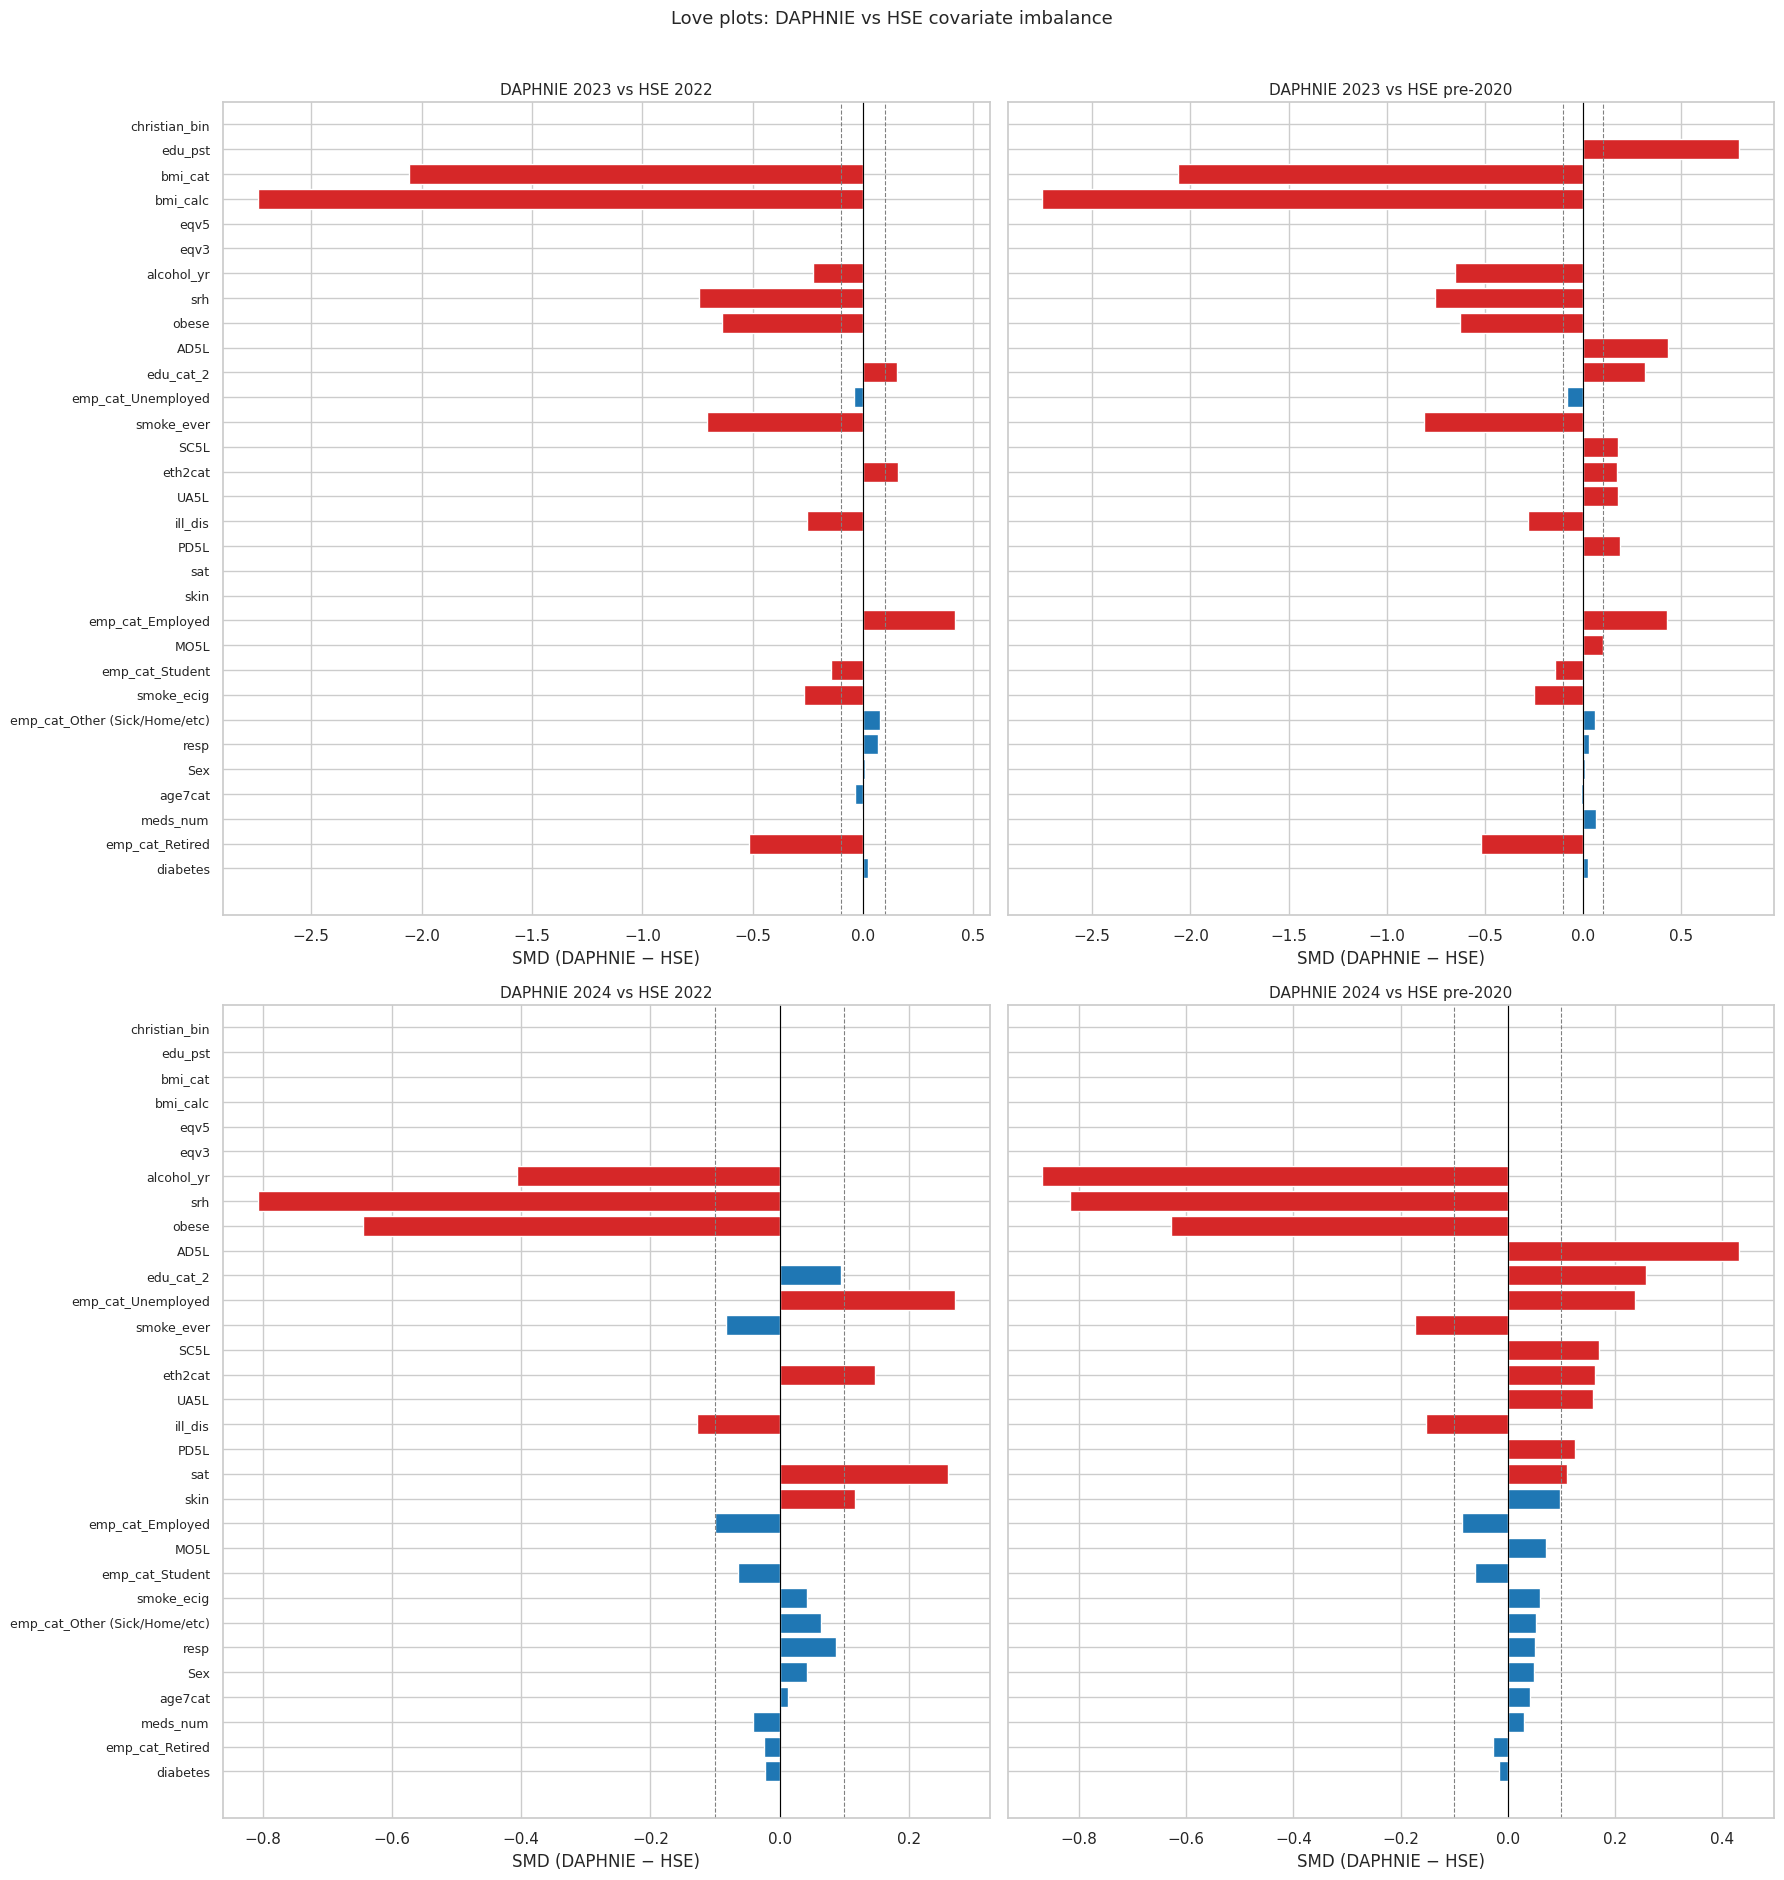

In [41]:
# 2x2 Love plot: rows = DAPHNIE wave, columns = HSE target
# Variable order fixed by |SMD| in D2024 vs pre-2020 (primary comparison)
order = (
    smd_df["D2024 vs pre-2020"]
    .abs()
    .sort_values(ascending=True)
    .index.tolist()
)

panel_layout = [
    ("D2023 vs HSE2022",  "DAPHNIE 2023 vs HSE 2022"),
    ("D2023 vs pre-2020", "DAPHNIE 2023 vs HSE pre-2020"),
    ("D2024 vs HSE2022",  "DAPHNIE 2024 vs HSE 2022"),
    ("D2024 vs pre-2020", "DAPHNIE 2024 vs HSE pre-2020"),
]

n_vars = len(order)
fig, axes = plt.subplots(
    2, 2,
    figsize=(18, max(10, n_vars * 0.6)),
    sharey=True, sharex=False,
)

for ax, (col_key, title) in zip(axes.flat, panel_layout):
    smds = smd_df[col_key].reindex(order)
    colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds]
    ax.barh(range(n_vars), smds.values, color=colors)
    ax.set_yticks(range(n_vars))
    ax.set_yticklabels(order, fontsize=9)
    ax.axvline(0,    color="black", linewidth=0.8)
    ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("SMD (DAPHNIE − HSE)")

fig.suptitle("Love plots: DAPHNIE vs HSE covariate imbalance", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_daphnie_vs_hse.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
# Variables imbalanced (|SMD| > 0.1) in at least one comparison
imbalanced = (
    smd_df[smd_df.abs().gt(0.1).any(axis=1)]
    .sort_values("D2023 vs HSE2022", key=abs, ascending=False)
)

print(f"Variables with |SMD| > 0.1 in at least one comparison: {len(imbalanced)}")
display(imbalanced.round(3))

Variables with |SMD| > 0.1 in at least one comparison: 22


,D2023 vs HSE2022,D2024 vs HSE2022,D2023 vs pre-2020,D2024 vs pre-2020
variable,,,,
bmi_calc,-2.742,NaN,-2.754,NaN
bmi_cat,-2.056,NaN,-2.066,NaN
srh,-0.744,-0.807,-0.754,-0.816
smoke_ever,-0.708,-0.083,-0.810,-0.173
obese,-0.640,-0.645,-0.624,-0.629
emp_cat_Retired,-0.518,-0.025,-0.521,-0.028
emp_cat_Employed,0.415,-0.100,0.429,-0.086
smoke_ecig,-0.268,0.043,-0.251,0.060
ill_dis,-0.255,-0.127,-0.281,-0.153
